<a href="https://colab.research.google.com/github/springboardmentor2507-alt/AI-Powered-NIDS/blob/Charitha-Pendyala/milestone_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loading Dataset and assigning columns**

In [16]:
import pandas as pd

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label","difficulty"
]

df = pd.read_csv("KDDTrain+_20Percent.txt", header=None)
df.columns = columns

print("Raw data loaded:", df.shape)


Raw data loaded: (25192, 43)


**Defining Attack Category Lists for NSL-KDD Classification**

In [17]:
dos_attacks = [
    'back','land','neptune','pod','smurf','teardrop',
    'apache2','mailbomb','processtable','udpstorm'
]

probe_attacks = [
    'satan','ipsweep','nmap','portsweep','mscan','saint'
]

r2l_attacks = [
    'guess_passwd','ftp_write','imap','phf','multihop',
    'warezmaster','warezclient','spy','xlock','xsnoop',
    'snmpgetattack','snmpguess','httptunnel','sendmail','named'
]

u2r_attacks = [
    'buffer_overflow','rootkit','perl','loadmodule','ps','sqlattack','xterm'
]

print("\nSTEP 3: ATTACK CATEGORY LISTS DEFINED")
print("DoS attacks:", dos_attacks)
print("Probe attacks:", probe_attacks)
print("R2L attacks:", r2l_attacks)
print("U2R attacks:", u2r_attacks)


STEP 3: ATTACK CATEGORY LISTS DEFINED
DoS attacks: ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop', 'apache2', 'mailbomb', 'processtable', 'udpstorm']
Probe attacks: ['satan', 'ipsweep', 'nmap', 'portsweep', 'mscan', 'saint']
R2L attacks: ['guess_passwd', 'ftp_write', 'imap', 'phf', 'multihop', 'warezmaster', 'warezclient', 'spy', 'xlock', 'xsnoop', 'snmpgetattack', 'snmpguess', 'httptunnel', 'sendmail', 'named']
U2R attacks: ['buffer_overflow', 'rootkit', 'perl', 'loadmodule', 'ps', 'sqlattack', 'xterm']


**Creating a Function to Map Raw Attack Labels to Attack Categories**

In [18]:
def map_attack_category(label):
    if label in dos_attacks:
        return "DoS"
    elif label in probe_attacks:
        return "Probe"
    elif label in r2l_attacks:
        return "R2L"
    elif label in u2r_attacks:
        return "U2R"
    elif label == "normal":
        return "normal"
    else:
        return "unknown"

In [19]:
df["attack_category"] = df["label"].apply(map_attack_category)

print("\nSTEP 5: AFTER MAPPING RAW LABELS \u2192 ATTACK CATEGORIES")
print(df[["label", "attack_category"]].head(20))  # show more rows

print("\nCategory Counts:")
print(df["attack_category"].value_counts())
df["attack_category"].value_counts()


STEP 5: AFTER MAPPING RAW LABELS → ATTACK CATEGORIES
          label attack_category
0        normal          normal
1        normal          normal
2       neptune             DoS
3        normal          normal
4        normal          normal
5       neptune             DoS
6       neptune             DoS
7       neptune             DoS
8       neptune             DoS
9       neptune             DoS
10      neptune             DoS
11      neptune             DoS
12       normal          normal
13  warezclient             R2L
14      neptune             DoS
15      neptune             DoS
16       normal          normal
17      ipsweep           Probe
18       normal          normal
19       normal          normal

Category Counts:
attack_category
normal    13449
DoS        9234
Probe      2289
R2L         209
U2R          11
Name: count, dtype: int64


,count
attack_category,
normal,13449
DoS,9234
Probe,2289
R2L,209
U2R,11


**Checking the Dataset for Missing Values**

In [20]:
print("\nSTEP 6: CHECKING FOR MISSING VALUES")
print(df.isnull().sum())



STEP 6: CHECKING FOR MISSING VALUES
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_s

**Identifying and Removing Duplicate Rows from the Dataset**

In [21]:
print("\nSTEP 7: REMOVING DUPLICATE ROWS")
before = df.shape[0]

df.drop_duplicates(inplace=True)

after = df.shape[0]
print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)



STEP 7: REMOVING DUPLICATE ROWS
Rows before: 25192
Rows after: 25192
Duplicates removed: 0


**Splitting the Dataset into Training and Testing Sets**

In [22]:
from sklearn.model_selection import train_test_split

print("\nSTEP 11: TRAIN–TEST SPLIT")

# Filter out the 'unknown' category as it has only one sample, causing issues with stratification
df_filtered = df[df['attack_category'] != 'unknown']

X = df_filtered.drop(columns=["label", "attack_category"])
y = df_filtered["attack_category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)


STEP 11: TRAIN–TEST SPLIT
Training set shape: (20153, 42)
Testing set shape: (5039, 42)
Training labels shape: (20153,)
Testing labels shape: (5039,)


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define X_unsup first, which is used later in this cell
X_unsup = df.drop(columns=["label", "attack_category"], errors='ignore')

# Define categorical and numerical columns for preprocessing
# These rely on X_train.columns, which is defined by a previously executed cell
cat_cols = ["protocol_type", "service", "flag"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# --------------------------------------------------
# FIT PREPROCESSOR ONLY ON TRAINING DATA (ONCE)
# --------------------------------------------------
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
X_unsup_proc = preprocessor.transform(X_unsup)


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ["protocol_type", "service", "flag"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


**Attack Category Distribution**


VISUAL 1: ATTACK CATEGORY DISTRIBUTION


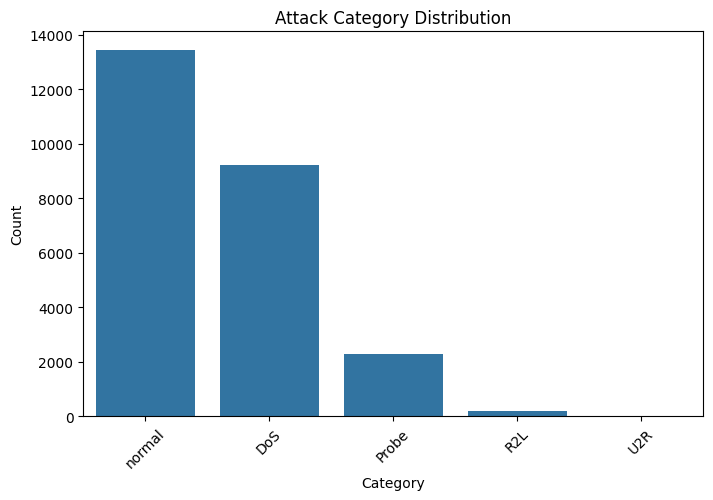

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nVISUAL 1: ATTACK CATEGORY DISTRIBUTION")

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="attack_category", order=df["attack_category"].value_counts().index)
plt.title("Attack Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()



VISUAL 3: CORRELATION HEATMAP


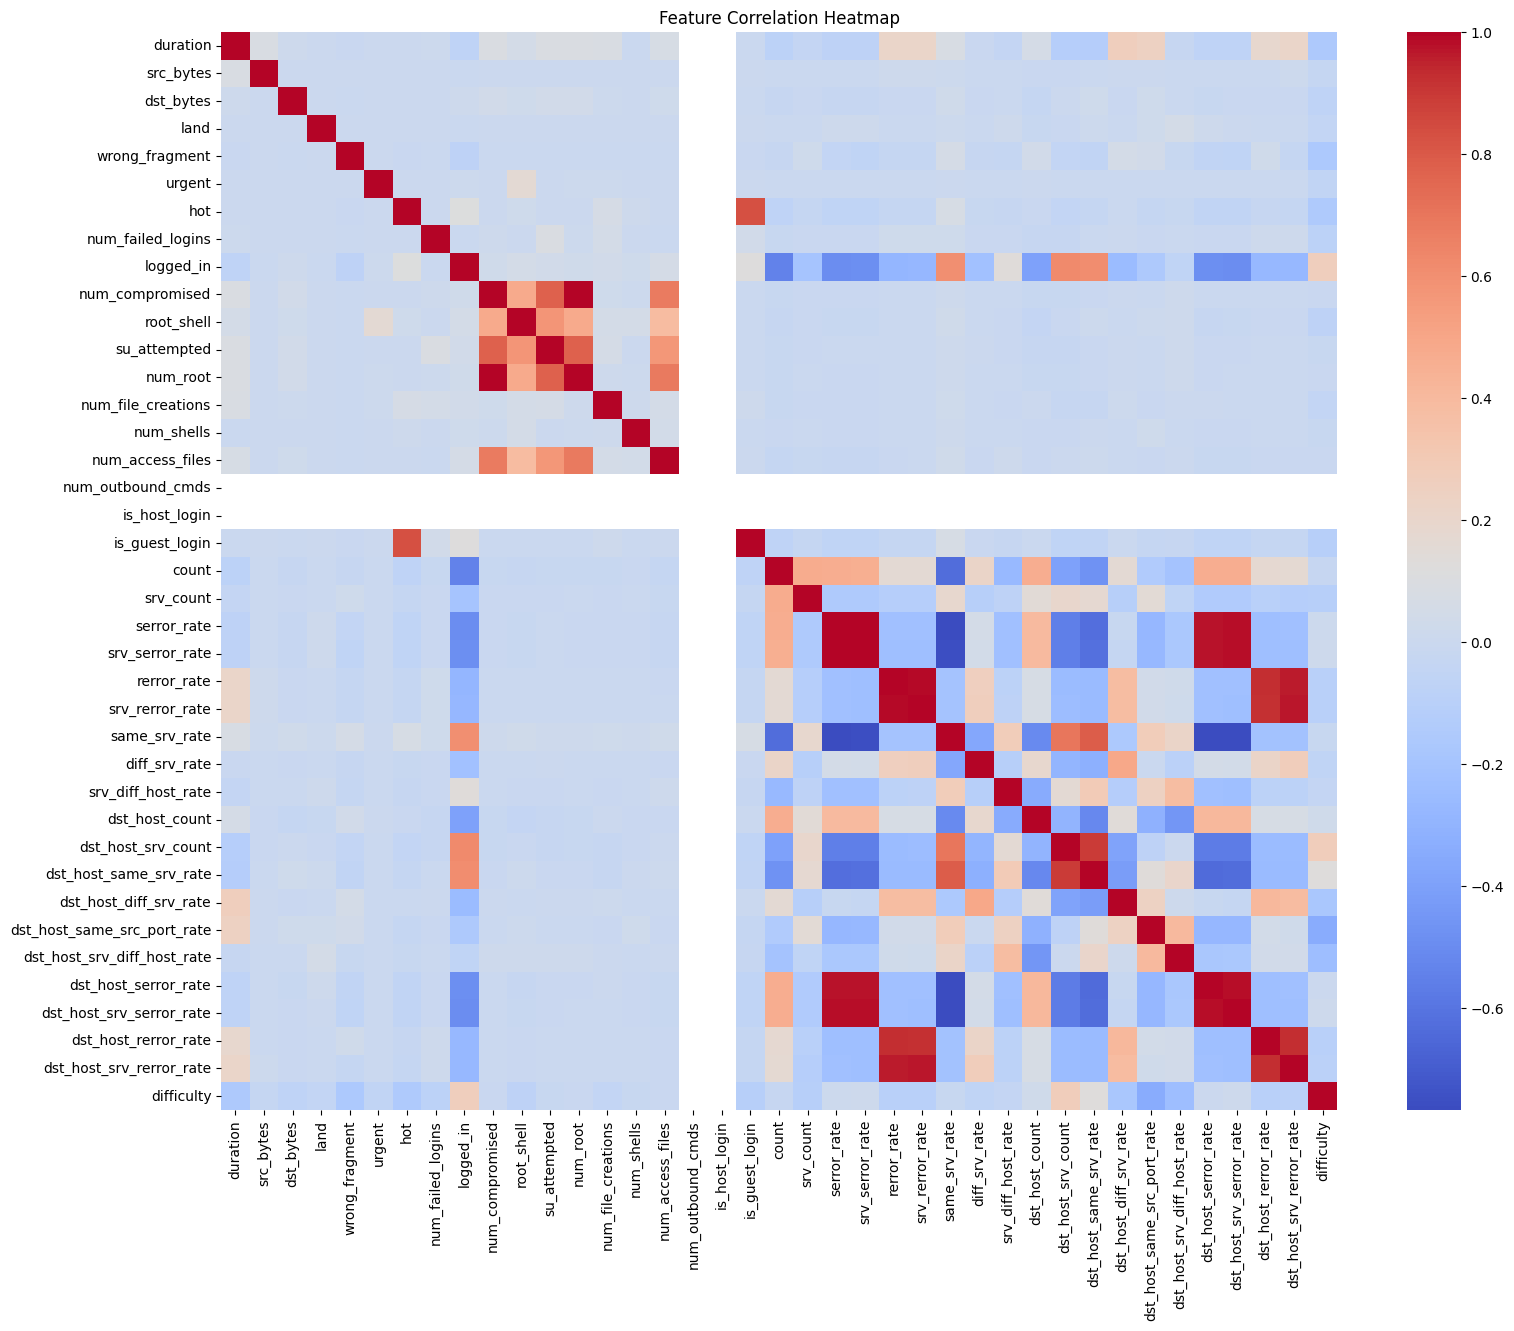

In [26]:
import numpy as np

print("\nVISUAL 3: CORRELATION HEATMAP")

plt.figure(figsize=(18,14))
# Select only numerical columns for correlation calculation
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

**Histogram of Key Features**


VISUAL 4: HISTOGRAMS OF IMPORTANT FEATURES


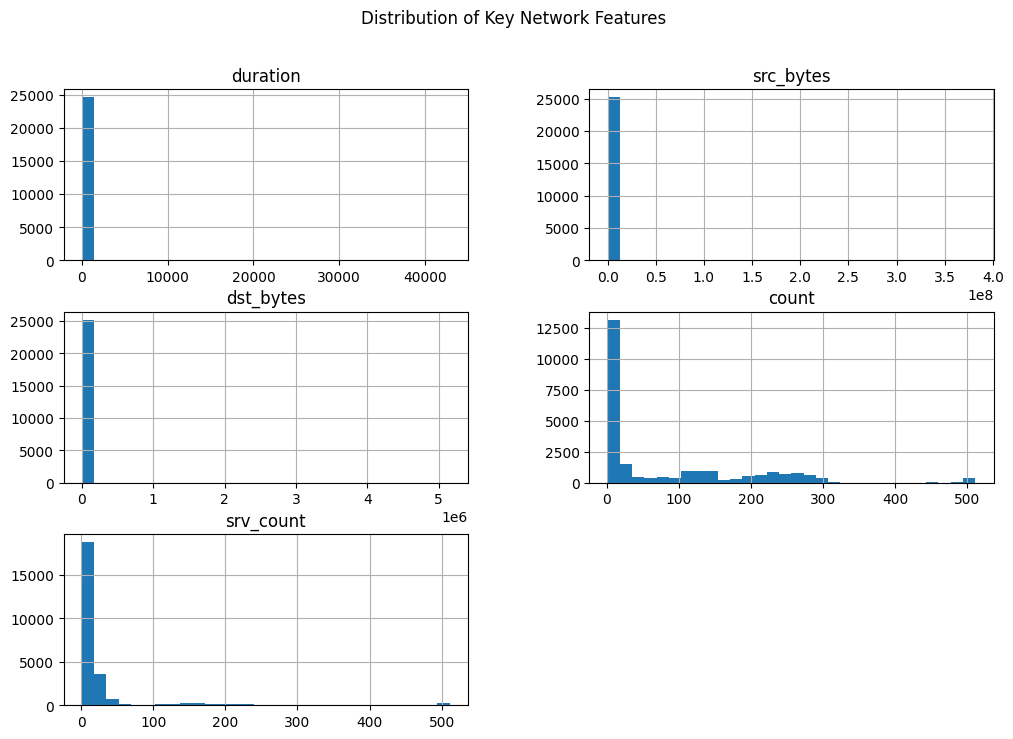

In [27]:
print("\nVISUAL 4: HISTOGRAMS OF IMPORTANT FEATURES")

key_features = ["duration", "src_bytes", "dst_bytes", "count", "srv_count"]

df[key_features].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Key Network Features")
plt.show()


**FEATURE IMPORTANCE (RANDOM FOREST)**

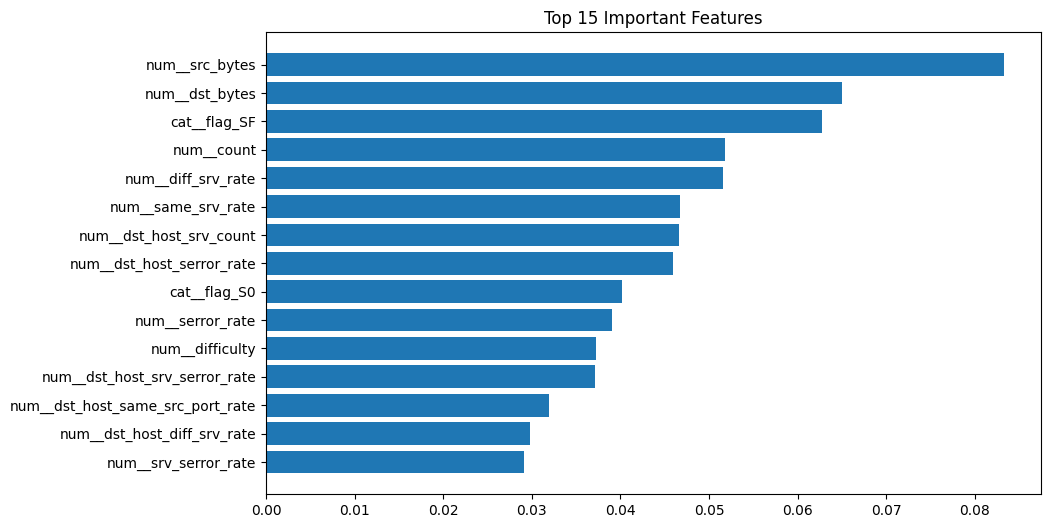

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipe.fit(X_train, y_train)

importances = rf_pipe.named_steps["model"].feature_importances_
feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()

indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10,6))
plt.barh(feature_names[indices], importances[indices])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.show()


**PCA VISUALIZATION**

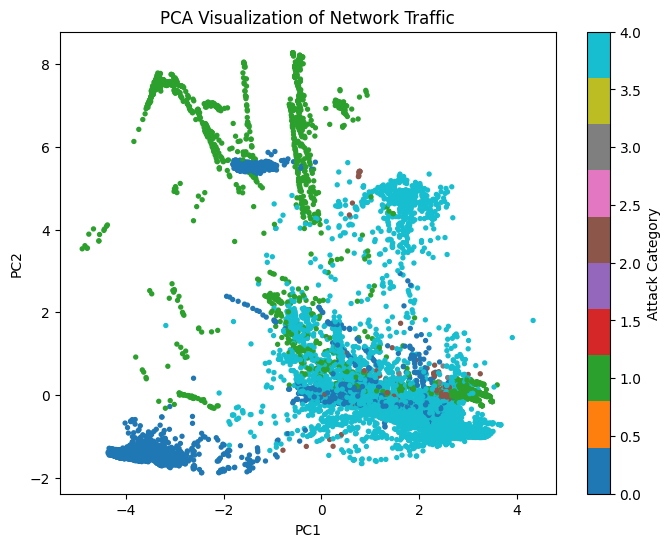

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_unsup_proc)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["attack_category"].astype("category").cat.codes,
    cmap="tab10",
    s=8
)
plt.title("PCA Visualization of Network Traffic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Attack Category")
plt.show()


**TRAINING SUPERVISED MODELS**

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n===== {model.__class__.__name__} =====")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("\nClassification Report:\n", classification_report(y_test, preds))

    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_,
                yticklabels=model.classes_)
    plt.title(f"{model.__class__.__name__} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy_score(y_test, preds)


**TRAIN MULTIPLE MODELS**


STEP 15: TRAINING SUPERVISED MODELS

===== Pipeline =====
Accuracy: 0.9908712046040881

Classification Report:
               precision    recall  f1-score   support

         DoS       0.99      1.00      1.00      1847
       Probe       0.97      0.98      0.97       458
         R2L       0.93      0.93      0.93        42
         U2R       1.00      0.50      0.67         2
      normal       0.99      0.99      0.99      2690

    accuracy                           0.99      5039
   macro avg       0.98      0.88      0.91      5039
weighted avg       0.99      0.99      0.99      5039



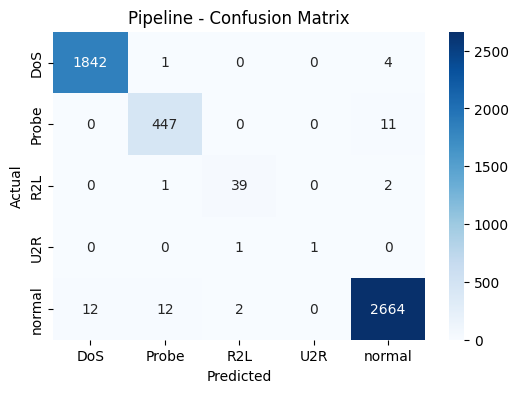


===== Pipeline =====
Accuracy: 0.9974201230402858

Classification Report:
               precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      1847
       Probe       0.99      1.00      0.99       458
         R2L       1.00      0.95      0.98        42
         U2R       0.00      0.00      0.00         2
      normal       1.00      1.00      1.00      2690

    accuracy                           1.00      5039
   macro avg       0.80      0.79      0.79      5039
weighted avg       1.00      1.00      1.00      5039



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


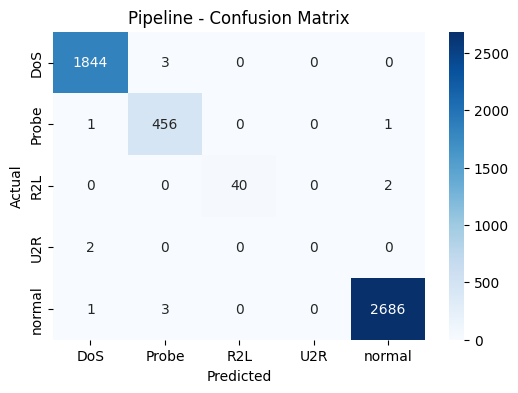


===== Pipeline =====
Accuracy: 0.9984123834094066

Classification Report:
               precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      1847
       Probe       1.00      1.00      1.00       458
         R2L       1.00      0.93      0.96        42
         U2R       0.00      0.00      0.00         2
      normal       1.00      1.00      1.00      2690

    accuracy                           1.00      5039
   macro avg       0.80      0.78      0.79      5039
weighted avg       1.00      1.00      1.00      5039



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


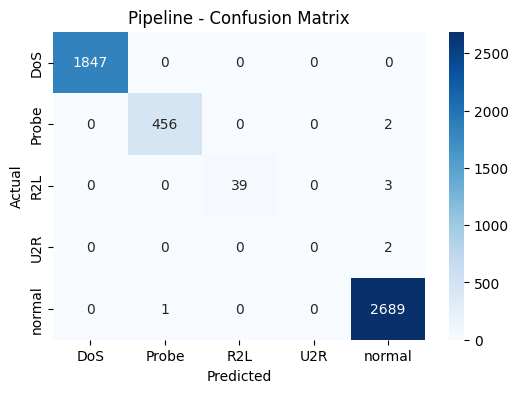


===== Pipeline =====
Accuracy: 0.9968247668188133

Classification Report:
               precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      1847
       Probe       0.98      1.00      0.99       458
         R2L       0.97      0.93      0.95        42
         U2R       1.00      0.50      0.67         2
      normal       1.00      1.00      1.00      2690

    accuracy                           1.00      5039
   macro avg       0.99      0.88      0.92      5039
weighted avg       1.00      1.00      1.00      5039



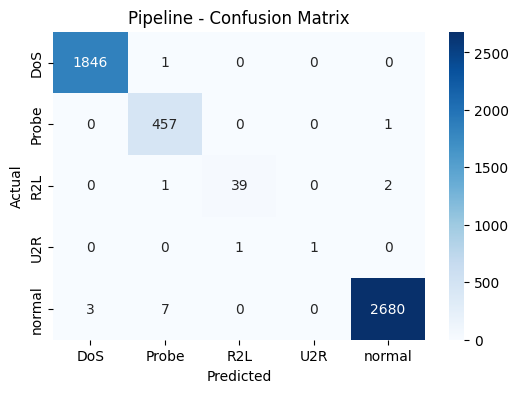

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

models = [
    Pipeline([("preprocess", preprocessor), ("model", LogisticRegression(max_iter=300))]),
    Pipeline([("preprocess", preprocessor), ("model", DecisionTreeClassifier(random_state=42))]),
    Pipeline([("preprocess", preprocessor), ("model", RandomForestClassifier(n_estimators=200, random_state=42))]),
    Pipeline([("preprocess", preprocessor), ("model", SVC(kernel='rbf', gamma='scale'))])
]

model_names = []
accuracies = []

print("\nSTEP 15: TRAINING SUPERVISED MODELS")

for m in models:
    acc = evaluate_model(m)
    model_names.append(m.named_steps["model"].__class__.__name__)
    accuracies.append(acc)


**MODEL COMPARISON (BAR CHART)**

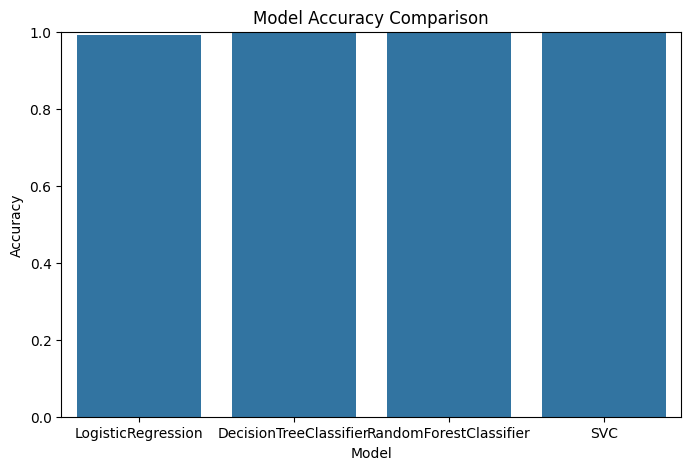

LogisticRegression: 0.9909
DecisionTreeClassifier: 0.9974
RandomForestClassifier: 0.9984
SVC: 0.9968


In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x=model_names, y=accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

for name, acc in zip(model_names, accuracies):
    print(f"{name}: {acc:.4f}")


**Prepare Data for Anomaly Detection**

In [33]:
print("\nSTEP 17: PREPARING DATA FOR ANOMALY DETECTION")

X_unsup = df.drop(columns=["label", "attack_category"], errors='ignore') # Use errors='ignore' in case attack_category is missing temporarily
print("Unsupervised data shape:", X_unsup.shape)


STEP 17: PREPARING DATA FOR ANOMALY DETECTION
Unsupervised data shape: (25192, 42)


**Isolation Forest (Core Anomaly Detection Model)**

In [34]:
from sklearn.ensemble import IsolationForest

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.15,
    random_state=42
)

iso_forest.fit(X_train_proc)
test_anomaly = iso_forest.predict(X_test_proc)

In [35]:
X_unsup_proc = preprocessor.transform(X_unsup)
df["anomaly_score"] = iso_forest.predict(X_unsup_proc)

df["anomaly"] = df["anomaly_score"].map({1: "Normal", -1: "Anomaly"})

print(df["anomaly"].value_counts())

anomaly
Normal     21419
Anomaly     3773
Name: count, dtype: int64


**Visualization 1 — Anomaly Count**

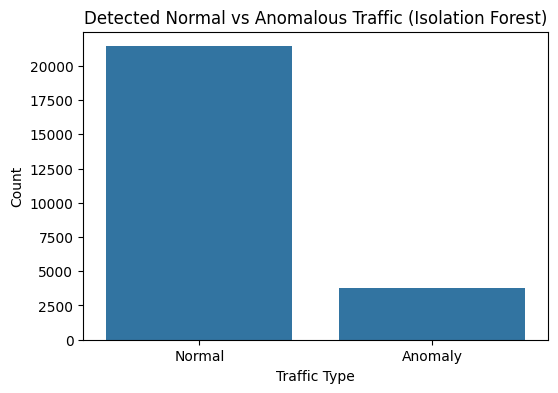

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="anomaly", data=df)
plt.title("Detected Normal vs Anomalous Traffic (Isolation Forest)")
plt.xlabel("Traffic Type")
plt.ylabel("Count")
plt.show()


**PCA Visualization of Anomalies**

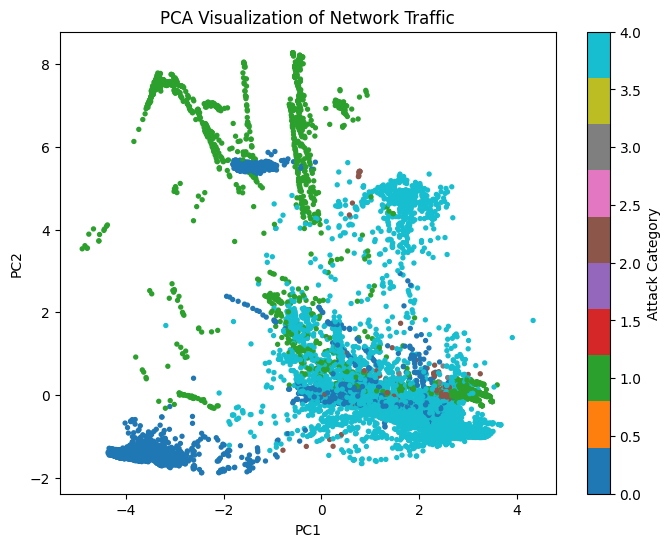

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_unsup_proc)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=df["attack_category"].astype("category").cat.codes,
    cmap="tab10",
    s=8
)
plt.title("PCA Visualization of Network Traffic")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Attack Category")
plt.show()


**Compare Anomalies with Actual Attack Categories (Analysis)**

In [38]:
print("\nSTEP 21: ANOMALY vs ACTUAL ATTACK CATEGORY")

comparison = pd.crosstab(df["attack_category"], df["anomaly"])
print(comparison)



STEP 21: ANOMALY vs ACTUAL ATTACK CATEGORY
anomaly          Anomaly  Normal
attack_category                 
DoS                  961    8273
Probe               1766     523
R2L                   60     149
U2R                    6       5
normal               980   12469



VISUALIZATION: ANOMALY DETECTION BREAKDOWN BY ATTACK CATEGORY


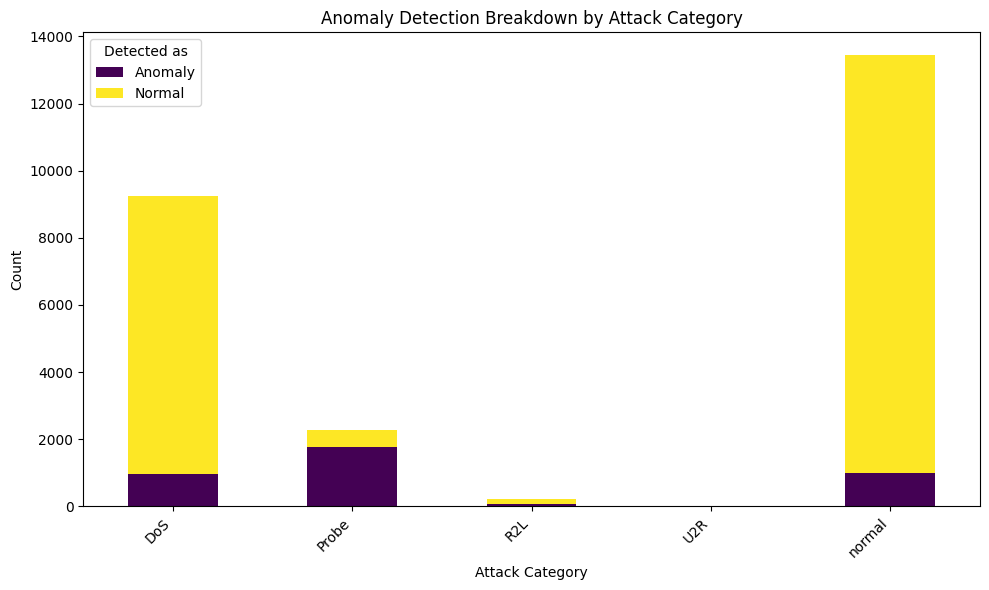

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nVISUALIZATION: ANOMALY DETECTION BREAKDOWN BY ATTACK CATEGORY")

# Create a stacked bar chart from the comparison DataFrame
comparison.plot(kind='bar', stacked=True, figsize=(10, 6), cmap='viridis')
plt.title('Anomaly Detection Breakdown by Attack Category')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Detected as')
plt.tight_layout()
plt.show()


**K-Means Clustering (Secondary Unsupervised Method)**

In [40]:
from sklearn.cluster import KMeans

print("\nSTEP 22: K-MEANS CLUSTERING")

kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster"] = kmeans.fit_predict(X_unsup_proc)


print(df["cluster"].value_counts())


STEP 22: K-MEANS CLUSTERING
cluster
0    25182
1       10
Name: count, dtype: int64


**Visualization: K-Means Clusters (PCA)**

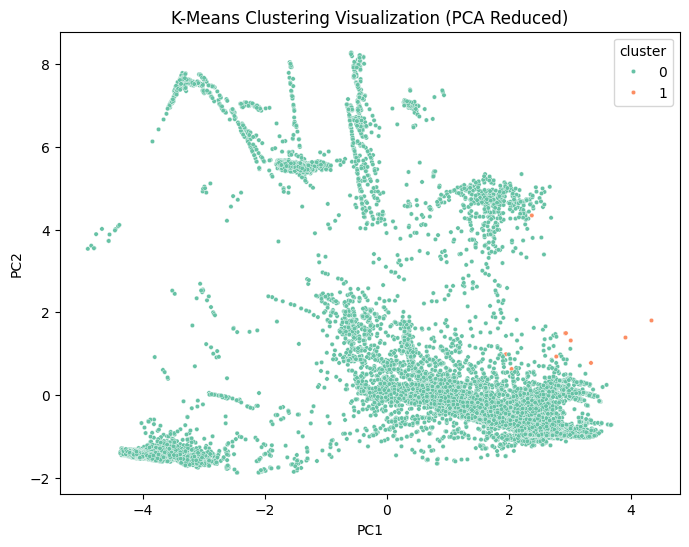

In [41]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["cluster"],
    palette="Set2",
    s=10
)
plt.title("K-Means Clustering Visualization (PCA Reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


**Train Best Supervised Model (Random Forest)**

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

best_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

best_model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'land',
                                                   'wrong_fragment', 'urgent',
                                                   'hot', 'num_failed_logins',
                                                   'logged_in',
                                                   'num_compromised',
                                                   'root_shell', 'su_attempted',
                                                   'num_root',
                                                   'num_file_creations',
                                                   'num_shells',
                                                   'num_access_files',
                                                   'num_outbound_cmds',
                                                   'is_host_login',
                                                   'is_guest_l...
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['protocol_type', 'service',
                                                   'flag'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

**Simulate Real-Time Predictions (Batch-Based)**

In [43]:
# Copy test data
df_test = X_test.copy()

# Supervised predictions
df_test["predicted_attack"] = best_model.predict(X_test)

# Prediction confidence
df_test["attack_confidence"] = best_model.predict_proba(X_test).max(axis=1)


**Attach Anomaly Detection Results**

In [44]:
# Anomaly labels from Isolation Forest
df_test["anomaly_label"] = test_anomaly
df_test["anomaly"] = df_test["anomaly_label"].map({1: "Normal", -1: "Anomaly"})

# Anomaly score (lower = more anomalous)
df_test["anomaly_score"] = iso_forest.decision_function(X_test_proc)


**Define Severity-Based Alert Rules (IMPROVED)**

In [45]:
def generate_alert(row):
    # High-confidence supervised attack
    if row["predicted_attack"] != "normal" and row["attack_confidence"] > 0.80:
        return "CRITICAL"

    # Strong anomaly detection
    if row["anomaly"] == "Anomaly" and row["anomaly_score"] < -0.15:
        return "HIGH"

    # Weak anomaly or low-confidence attack
    if row["anomaly"] == "Anomaly" or row["predicted_attack"] != "normal":
        return "MEDIUM"

    return "SAFE"

df_test["alert_severity"] = df_test.apply(generate_alert, axis=1)


**Generate Alert Logs (SOC-Style)**

In [46]:
alerts = df_test[df_test["alert_severity"] != "SAFE"]

alerts_log = alerts[[
    "predicted_attack",
    "attack_confidence",
    "anomaly",
    "anomaly_score",
    "alert_severity"
]]

alerts_log.to_csv("intrusion_alerts_log.csv", index=False)

print("Alert log saved as intrusion_alerts_log.csv")


Alert log saved as intrusion_alerts_log.csv


**Visualize Alert Severity Distribution**

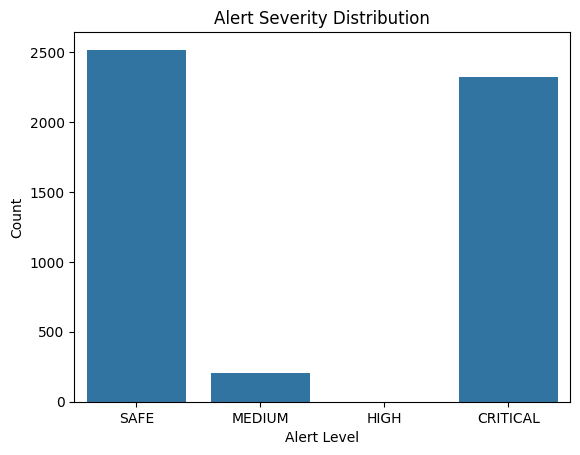

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="alert_severity",
    data=df_test,
    order=["SAFE", "MEDIUM", "HIGH", "CRITICAL"]
)

plt.title("Alert Severity Distribution")
plt.xlabel("Alert Level")
plt.ylabel("Count")
plt.show()


**Visualize Critical Attack Types**

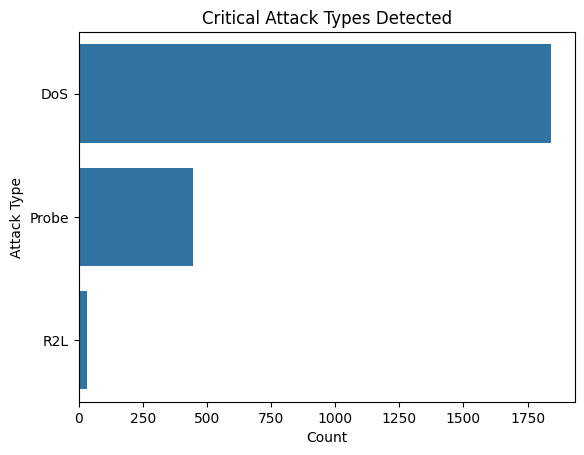

In [48]:
critical_alerts = alerts[alerts["alert_severity"] == "CRITICAL"]

sns.countplot(
    y="predicted_attack",
    data=critical_alerts
)

plt.title("Critical Attack Types Detected")
plt.xlabel("Count")
plt.ylabel("Attack Type")
plt.show()


**Batch-Based Streaming Simulation**

In [49]:
print("\nSimulating real-time traffic processing...\n")

for i in range(0, len(df_test), 50):
    batch = df_test.iloc[i:i+50]
    print(f"Processed traffic batch {i} to {i+50}")



Simulating real-time traffic processing...

Processed traffic batch 0 to 50
Processed traffic batch 50 to 100
Processed traffic batch 100 to 150
Processed traffic batch 150 to 200
Processed traffic batch 200 to 250
Processed traffic batch 250 to 300
Processed traffic batch 300 to 350
Processed traffic batch 350 to 400
Processed traffic batch 400 to 450
Processed traffic batch 450 to 500
Processed traffic batch 500 to 550
Processed traffic batch 550 to 600
Processed traffic batch 600 to 650
Processed traffic batch 650 to 700
Processed traffic batch 700 to 750
Processed traffic batch 750 to 800
Processed traffic batch 800 to 850
Processed traffic batch 850 to 900
Processed traffic batch 900 to 950
Processed traffic batch 950 to 1000
Processed traffic batch 1000 to 1050
Processed traffic batch 1050 to 1100
Processed traffic batch 1100 to 1150
Processed traffic batch 1150 to 1200
Processed traffic batch 1200 to 1250
Processed traffic batch 1250 to 1300
Processed traffic batch 1300 to 1350